In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("List of Countries by Sugarcane Production.csv")

In [3]:
df.shape

(103, 7)

In [4]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768.678.382,"3.668,531",10.226.205,"75.167,5"
1,1,India,Asia,348.448.000,260721,4.950.000,"70.393,5"
2,2,China,Asia,123.059.739,88287,1.675.215,"73.459,1"
3,3,Thailand,Asia,87.468.496,"1.264,303",1.336.575,"65.442,2"
4,4,Pakistan,Asia,65.450.704,324219,1.130.820,57.879


Data Cleaning

In [5]:
df["Production (Tons)"] = df["Production (Tons)"].str.replace(".","")
df["Production per Person (Kg)"] = df["Production per Person (Kg)"].str.replace(".","").str.replace(",",".")
df["Acreage (Hectare)"] = df["Acreage (Hectare)"].str.replace(".","")
df["Yield (Kg / Hectare)"]= df["Yield (Kg / Hectare)"].str.replace(".","").str.replace(",",".")

In [6]:
df.head()

,Unnamed: 0,Country,Continent,Production (Tons),Production per Person (Kg),Acreage (Hectare),Yield (Kg / Hectare)
0,0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,1,India,Asia,348448000,260721,4950000,70393.5
2,2,China,Asia,123059739,88287,1675215,73459.1
3,3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,4,Pakistan,Asia,65450704,324219,1130820,57879


In [7]:
df = df.drop( "Unnamed: 0", axis = 1)

In [8]:
df.rename(columns= {"Production (Tons)": "Production(Tons)"}, inplace = True)
df.rename(columns= {"Production per Person (Kg)": "Production_per_person(Kg)"}, inplace = True)
df.rename(columns= {"Acreage (Hectare)": "Acreage(Hectare)"}, inplace = True)
df.rename(columns= {"Yield (Kg / Hectare)": "Yield(Kg/Hectare)"}, inplace = True)

In [9]:
df.head()

,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


In [10]:
df.isna().sum()

Country                      0
Continent                    0
Production(Tons)             0
Production_per_person(Kg)    0
Acreage(Hectare)             1
Yield(Kg/Hectare)            1
dtype: int64

In [11]:
df[df["Acreage(Hectare)"].isnull()]

,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
99,Djibouti,Africa,53,51,NaN,NaN


In [12]:
df = df.dropna().reset_index().drop("index", axis = 1)

In [13]:
df

,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879
...,...,...,...,...,...,...
97,Spain,Europe,394,8,9,43596.5
98,Lebanon,Asia,97,16,3,28386.4
99,Singapore,Asia,50,9,2,25
100,Samoa,Oceania,12,6,1,11949.8


In [14]:
df.nunique()

Country                      102
Continent                      6
Production(Tons)             102
Production_per_person(Kg)    101
Acreage(Hectare)             101
Yield(Kg/Hectare)            102
dtype: int64

In [15]:
df.dtypes

Country                      object
Continent                    object
Production(Tons)             object
Production_per_person(Kg)    object
Acreage(Hectare)             object
Yield(Kg/Hectare)            object
dtype: object

In [16]:
df.dtypes

Country                      object
Continent                    object
Production(Tons)             object
Production_per_person(Kg)    object
Acreage(Hectare)             object
Yield(Kg/Hectare)            object
dtype: object

Univariate Analysis

In [17]:

df.head()

,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


How many countries produce sugarcane from each continent?

In [18]:

df["Continent"].value_counts()

Continent
Africa           38
Asia             25
North America    22
South America    11
Oceania           4
Europe            2
Name: count, dtype: int64

<Axes: xlabel='Continent'>

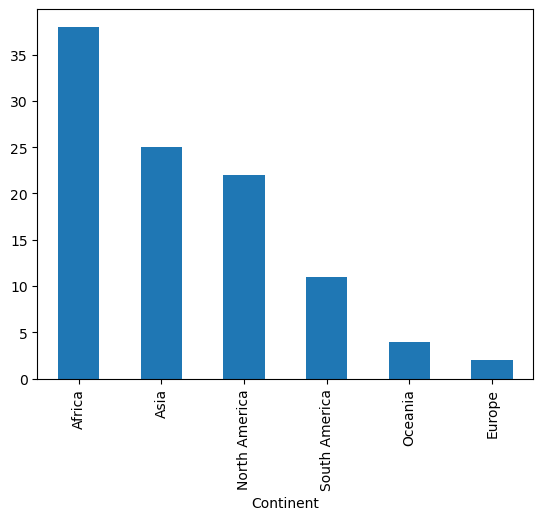

In [19]:
df["Continent"].value_counts().plot(kind = "bar")

Africa has maximum number of countries which produces sugarcane.

In [20]:
df.describe()

,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
count,102,102,102,102,102,102
unique,102,6,102,101,101,102
top,Brazil,Africa,768678382,297,584,75167.5
freq,1,38,1,2,2,1


Checking outliers

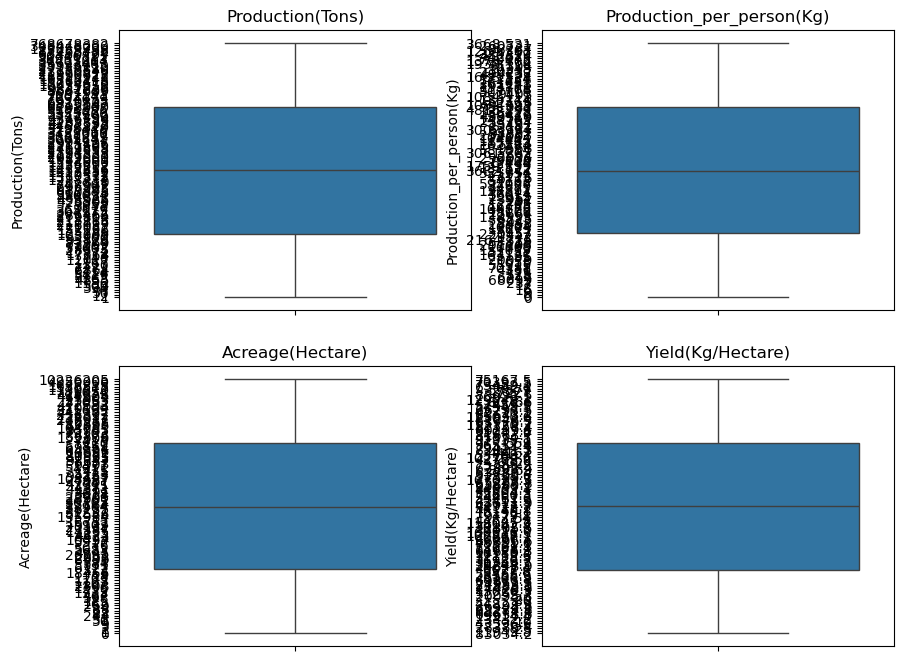

In [21]:
plt.figure(figsize = (10,8))
plt.subplot(2,2,1)
sns.boxplot(df["Production(Tons)"])
plt.title("Production(Tons)")
plt.subplot(2,2,2)
sns.boxplot(df["Production_per_person(Kg)"])
plt.title("Production_per_person(Kg)")
plt.subplot(2,2,3)
sns.boxplot(df["Acreage(Hectare)"])
plt.title("Acreage(Hectare)")
plt.subplot(2,2,4)
sns.boxplot(df["Yield(Kg/Hectare)"])
plt.title("Yield(Kg/Hectare)")
plt.show()

we have outliers in the data but outliers are required here as it shows the countries which has maximum production. And then we can see what are the reasons for outliers.

C:\Users\himan\AppData\Local\Temp\ipykernel_924\1909675950.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production(Tons)"])
C:\Users\himan\AppData\Local\Temp\ipykernel_924\1909675950.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Production_per_person(Kg)"])
C:\Users\himan\Ap

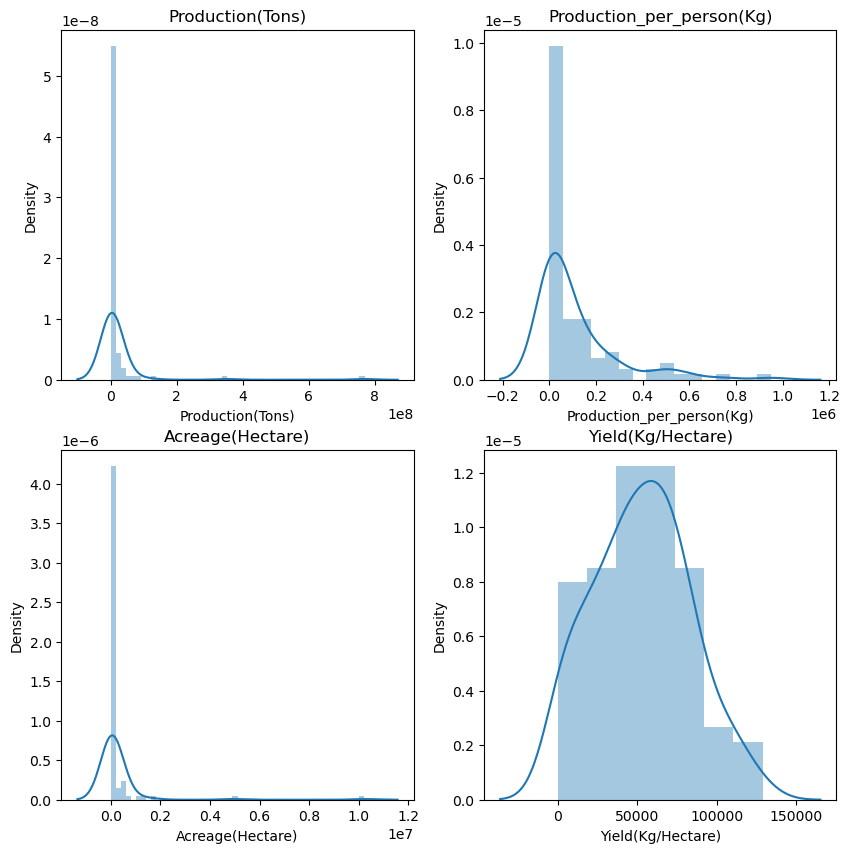

In [22]:
plt.figure(figsize = (10,10))
plt.subplot(2,2,1)
sns.distplot(df["Production(Tons)"])
plt.title("Production(Tons)")
plt.subplot(2,2,2)
sns.distplot(df["Production_per_person(Kg)"])
plt.title("Production_per_person(Kg)")
plt.subplot(2,2,3)
sns.distplot(df["Acreage(Hectare)"])
plt.title("Acreage(Hectare)")
plt.subplot(2,2,4)
sns.distplot(df["Yield(Kg/Hectare)"])
plt.title("Yield(Kg/Hectare)")
plt.show()

<Axes: ylabel='Production(Tons)'>

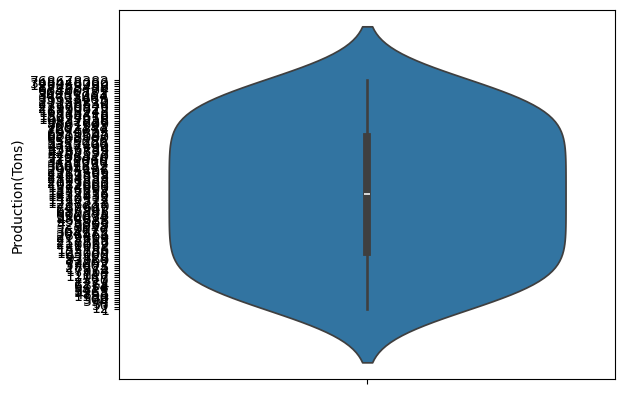

In [23]:
sns.violinplot(df["Production(Tons)"])

Bivariate Analysis

In [24]:
df.head()

,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


Which country produces maximum sugarcane?

In [25]:
df_new = df[["Country","Production(Tons)"]].set_index("Country")

In [26]:
df_new 

,Production(Tons)
Country,
Brazil,768678382
India,348448000
China,123059739
Thailand,87468496
Pakistan,65450704
...,...
Spain,394
Lebanon,97
Singapore,50


In [28]:
import pandas as pd

# Convert Production(Tons) column from string to numeric
df_new["Production(Tons)"] = pd.to_numeric(
    df_new["Production(Tons)"]
        .astype(str)
        .str.replace(",", ""),   # removes commas like "1,234"
    errors="coerce"            # invalid values become NaN
)

# Calculate percentage
df_new["Production(Tons)_percent"] = (
    df_new["Production(Tons)"] * 100 / df_new["Production(Tons)"].sum()
)

# Optional: round to 2 decimals
df_new["Production(Tons)_percent"] = df_new["Production(Tons)_percent"].round(2)

# View result
df_new.head()

,Production(Tons),Production(Tons)_percent
Country,,
Brazil,768678382,40.73
India,348448000,18.46
China,123059739,6.52
Thailand,87468496,4.63
Pakistan,65450704,3.47


<Axes: ylabel='Production(Tons)_percent'>

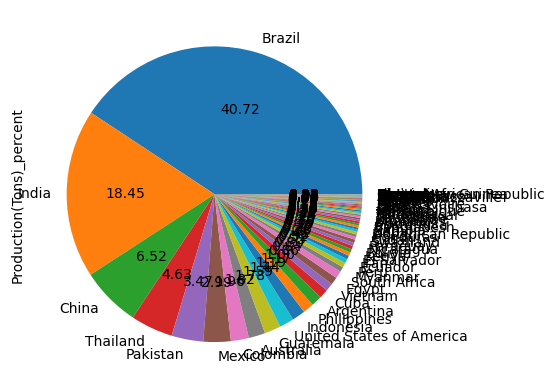

In [29]:
df_new["Production(Tons)_percent"].plot(kind = "pie", autopct = "%.2f")

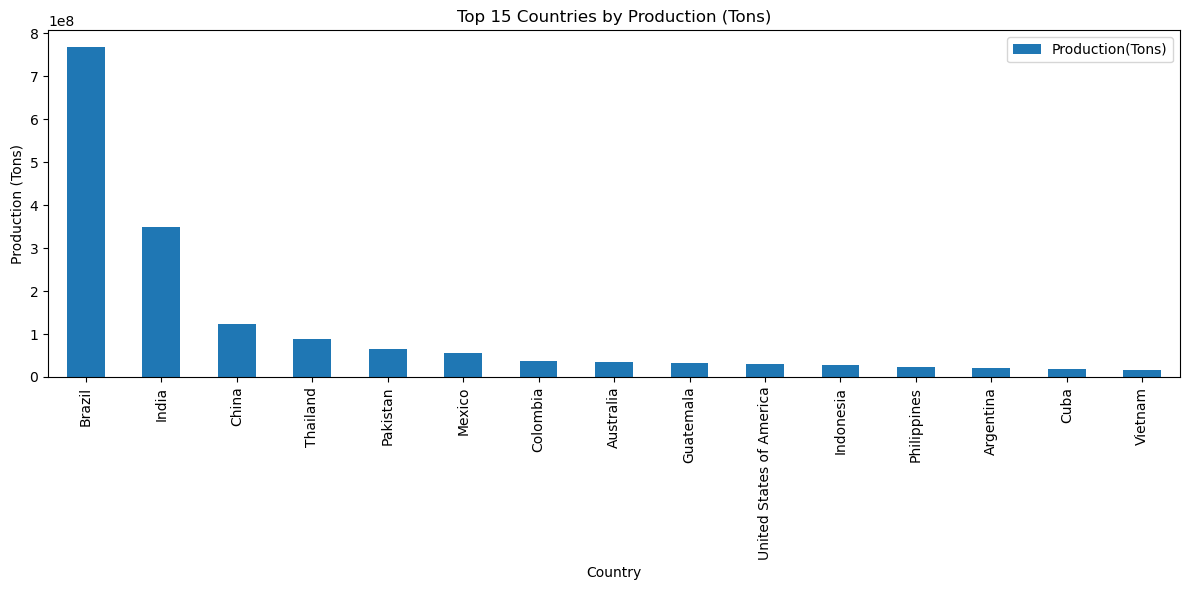

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert Production(Tons) to numeric (remove commas etc.)
df["Production(Tons)"] = pd.to_numeric(
    df["Production(Tons)"]
        .astype(str)
        .str.replace(",", ""),
    errors="coerce"
)

# Take top 15 countries by production
top15 = (
    df[["Country", "Production(Tons)"]]
    .dropna()
    .set_index("Country")
    .sort_values("Production(Tons)", ascending=False)
    .head(15)
)

# Plot bar chart
top15.plot(kind="bar", figsize=(12,6))

plt.title("Top 15 Countries by Production (Tons)")
plt.ylabel("Production (Tons)")
plt.xlabel("Country")
plt.tight_layout()
plt.show()

C:\Users\himan\AppData\Local\Temp\ipykernel_924\2823669880.py:2: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation =90)


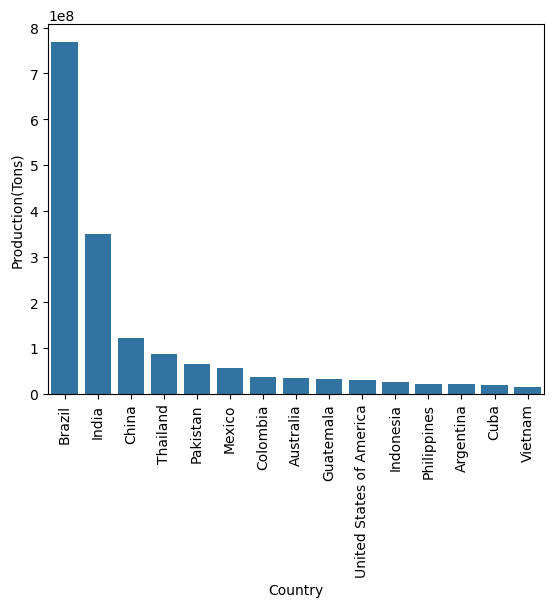

In [32]:
ax = sns.barplot(data = df.head(15),  x= "Country", y = "Production(Tons)")
ax.set_xticklabels(ax.get_xticklabels(),rotation =90)
plt.show()

The country "Brazil" produces maximum sugarcane out of all countries.


Which country has highest land?


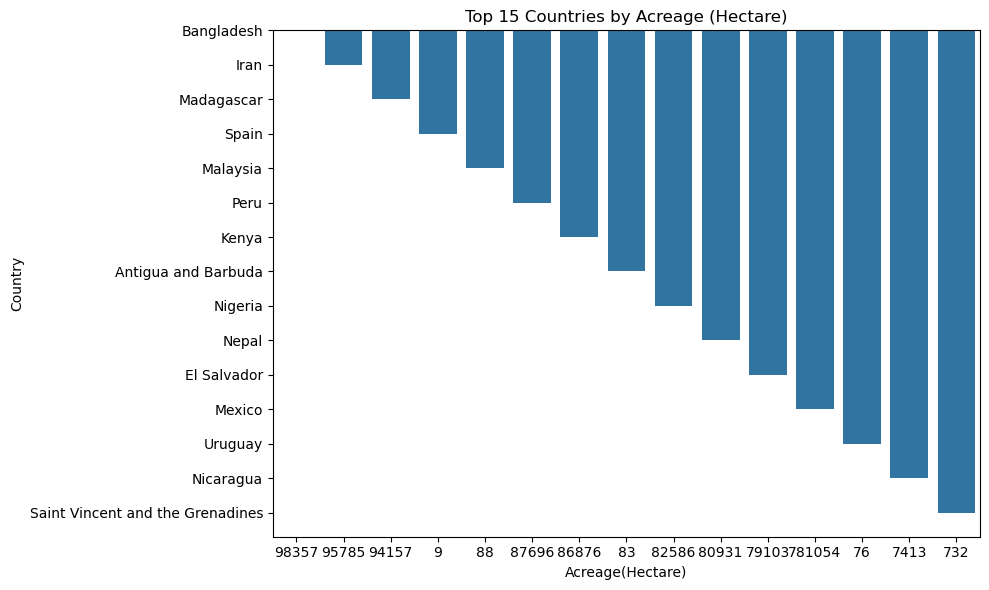

In [38]:
df_acr = df.sort_values("Acreage(Hectare)", ascending=False).head(15)

plt.figure(figsize=(10,6))
ax = sns.barplot(data=df_acr, y="Country", x="Acreage(Hectare)")

plt.title("Top 15 Countries by Acreage (Hectare)")
plt.tight_layout()
plt.show()

Which country has highest yield per hectare?

C:\Users\himan\AppData\Local\Temp\ipykernel_924\2860594357.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation =90)


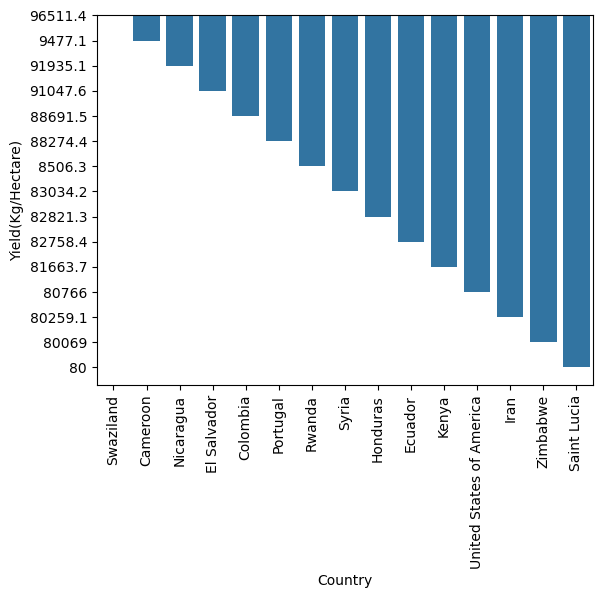

In [34]:
df_yield = df.sort_values("Yield(Kg/Hectare)", ascending = False).head(15)
ax = sns.barplot(data = df_yield,  x= "Country", y = "Yield(Kg/Hectare)")
ax.set_xticklabels(ax.get_xticklabels(),rotation =90)
plt.show()

Guatemala has the highest yield(kg/hectare)

Which country has highest production?

C:\Users\himan\AppData\Local\Temp\ipykernel_924\328127327.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation =90)


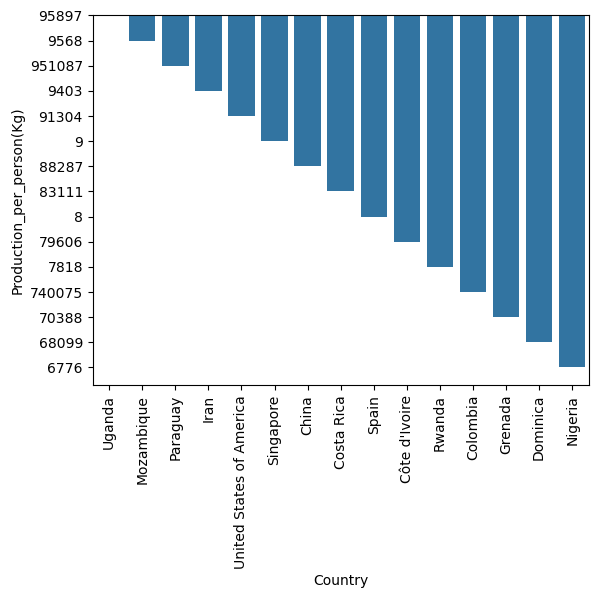

In [35]:
df_yield = df.sort_values("Production_per_person(Kg)", ascending = False).head(15)
ax = sns.barplot(data = df_yield,  x= "Country", y = "Production_per_person(Kg)")
ax.set_xticklabels(ax.get_xticklabels(),rotation =90)
plt.show()

Production per Person is highest in Paraguay

Correlation

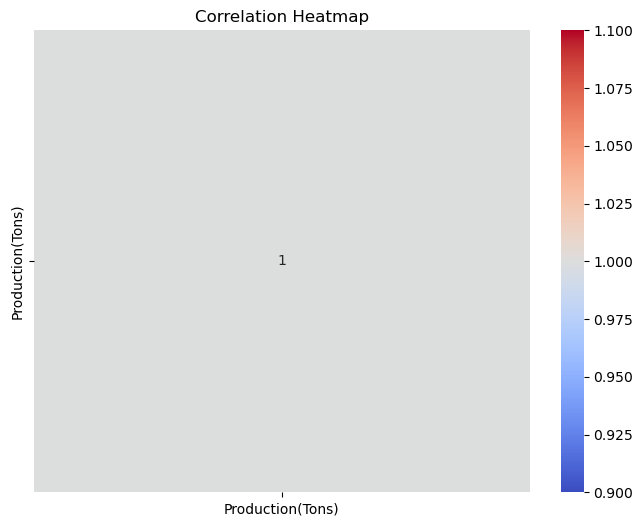

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

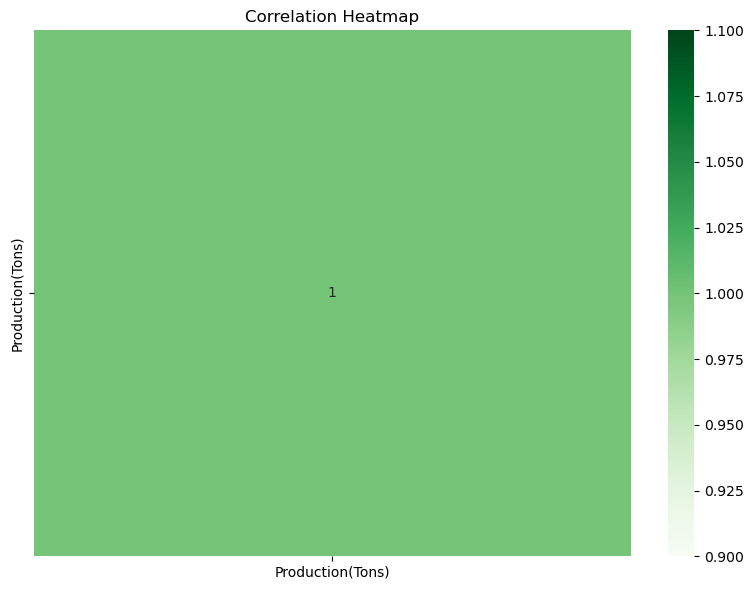

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="Greens")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Do countries with highest land produce more sugarcane?

<Axes: xlabel='Acreage(Hectare)', ylabel='Production(Tons)'>

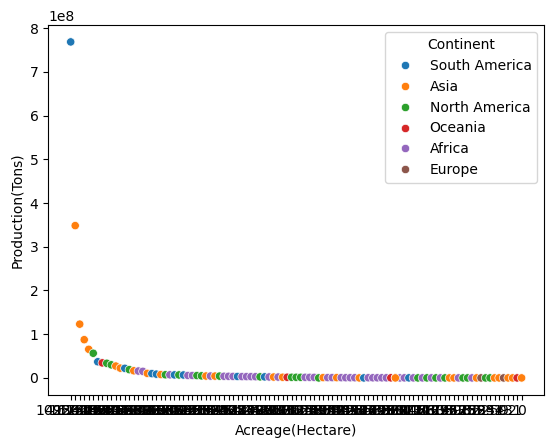

In [46]:
sns.scatterplot(data = df, x = "Acreage(Hectare)", y = "Production(Tons)", hue = "Continent" )

Overall increase in land increases the production

Do countries which yield more sugarcane per hectare produces more sugarcane in total?

<Axes: xlabel='Yield(Kg/Hectare)', ylabel='Production(Tons)'>

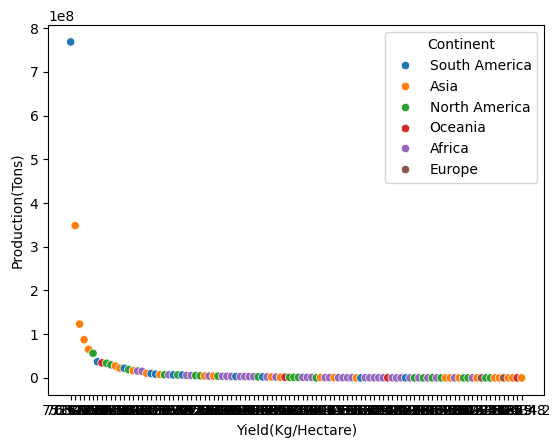

In [47]:
sns.scatterplot(data = df, x = "Yield(Kg/Hectare)" , y = "Production(Tons)", hue = "Continent")

In [48]:
df.head()

,Country,Continent,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare)
0,Brazil,South America,768678382,3668.531,10226205,75167.5
1,India,Asia,348448000,260721,4950000,70393.5
2,China,Asia,123059739,88287,1675215,73459.1
3,Thailand,Asia,87468496,1264.303,1336575,65442.2
4,Pakistan,Asia,65450704,324219,1130820,57879


Analysis for Continent

In [49]:
df_continent = df.groupby("Continent").sum()

In [50]:
df_continent["number_of_countries"] = df.groupby("Continent").count()["Country"]

In [51]:
df_continent

,Country,Production(Tons),Production_per_person(Kg),Acreage(Hectare),Yield(Kg/Hectare),number_of_countries
Continent,,,,,,
Africa,EgyptSouth AfricaKenyaSwazilandSudanZambiaMaur...,89681472,1616512611431392444816.2991354282537843002.994...,1370112469378687657851695644169551477549114359...,115030.661046.381663.796511.479424.5102789.673...,38
Asia,IndiaChinaThailandPakistanIndonesiaPhilippines...,721930425,260721882871264.303324219102482102321723341937...,4950000167521513365751130820472693410104256322...,70393.573459.165442.25787957455.554548.563643....,25
Europe,PortugalSpain,5823,5288,629,88274.443596.5,2
North America,MexicoGuatemalaUnited States of AmericaCubaEl ...,173995947,4525241938.114913041683.5281084.1111084.393594...,7810542598537053442307791037413646661068169033...,7227129049.38076642710.191047.691935.182821.34...,22
Oceania,AustraliaFijiPapua New GuineaSamoa,36177574,1373.4061759.199254556,4472043670569991,76929.142411.331128.911949.8,4
South America,BrazilColombiaArgentinaPeruEcuadorBoliviaParag...,865588126,3668.53174007549423731476850751861118951087104...,1022620541662633169987696104661152306120522344...,75167.588691.566297.5112120.282758.445374.5559...,11


Which continent produces maximum sugarcane?

<Axes: xlabel='Continent'>

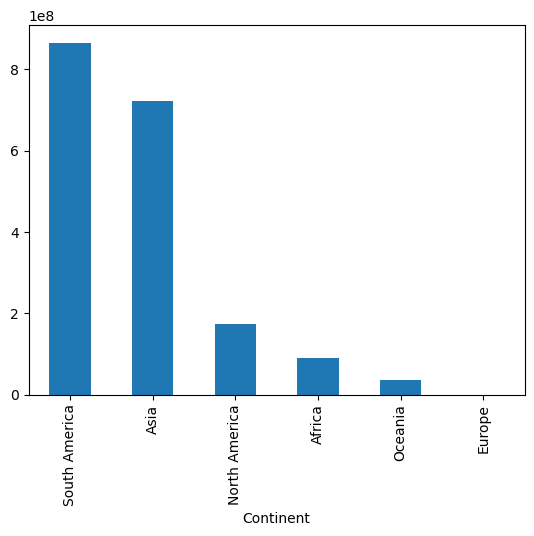

In [52]:
df_continent["Production(Tons)"].sort_values(ascending =  False).plot(kind = "bar")

Do number of countries in a Continent effects production of sugarcane?

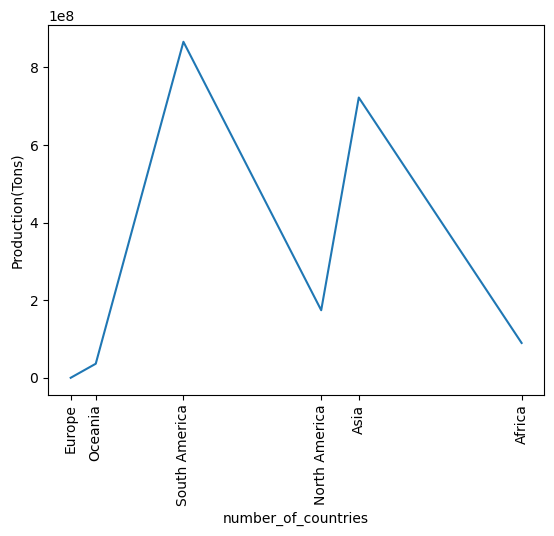

In [53]:
continent_names = df_continent.index.to_list()
sns.lineplot(data = df_continent,x = "number_of_countries", y= "Production(Tons)" )
plt.xticks(df_continent["number_of_countries"], continent_names, rotation =90)
plt.show()

Do continent with highest land produces more sugarcane?

<Axes: xlabel='Acreage(Hectare)', ylabel='Production(Tons)'>

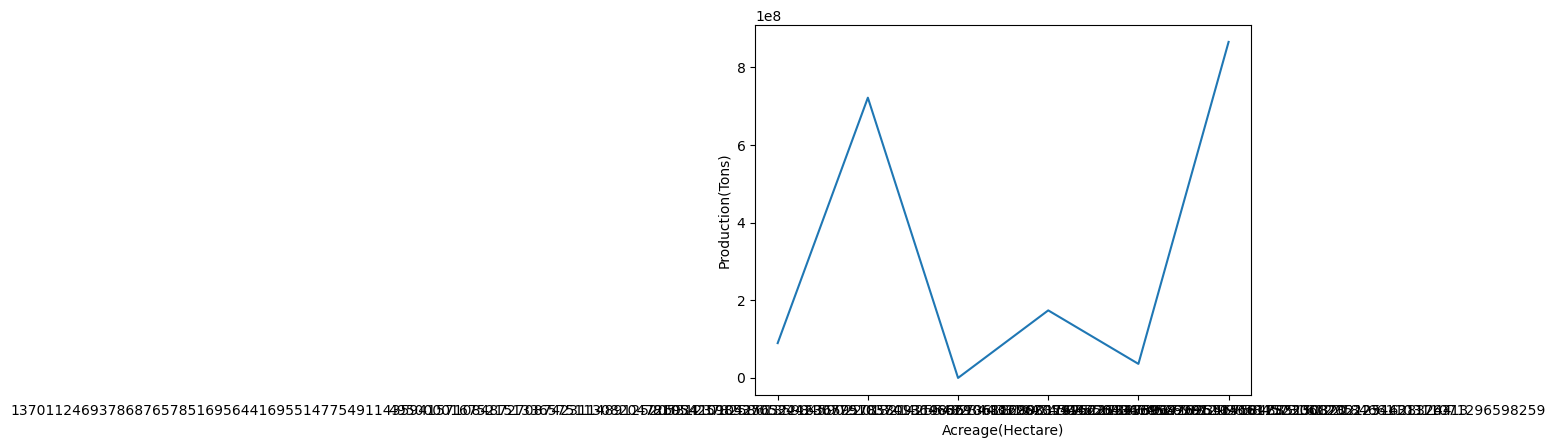

In [54]:
sns.lineplot(data = df_continent,x = "Acreage(Hectare)", y= "Production(Tons)" )

Production distribution by continent

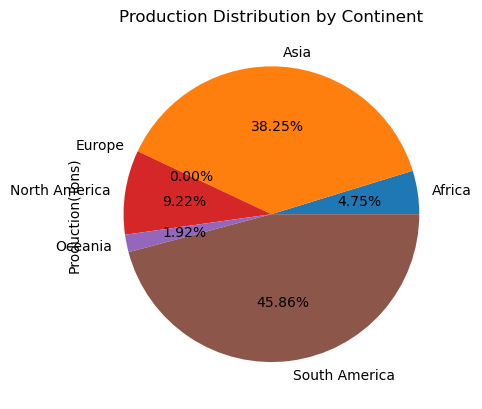

In [55]:
df_continent["Production(Tons)"].plot(kind = "pie", autopct = "%.2f%%")
plt.title('Production Distribution by Continent')
plt.show()

Correlation for continent

In [57]:
df_continent.select_dtypes(include="number").corr()

,Production(Tons),number_of_countries
Production(Tons),1.000000,0.109244
number_of_countries,0.109244,1.000000
